In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Verificar disponibilidade do PatchTST no neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE as NMAE

print("PatchTST disponível!")

# Carregar dataset
df_ml = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df_ml['data'] = pd.to_datetime(df_ml['data'])
df_ml = df_ml.sort_values('data').reset_index(drop=True)

# Formato neuralforecast
df_nf = df_ml[['data', 'casos']].copy()
df_nf.columns = ['ds', 'y']
df_nf['unique_id'] = 'MT'
df_nf['ds'] = pd.to_datetime(df_nf['ds'])
df_nf['y'] = df_nf['y'].astype(float)

h = 28
n_test = int(len(df_nf) * 0.20)
df_train = df_nf.iloc[:-n_test]
df_test = df_nf.iloc[-n_test:]

print(f"   Dataset: {df_nf.shape}")
print(f"   Treino: {len(df_train)} | Teste: {len(df_test)}")
print(f"   Período teste: {df_test['ds'].iloc[0].date()} → {df_test['ds'].iloc[-1].date()}")

✅ PatchTST disponível!
✅ Dataset: (2242, 3)
   Treino: 1794 | Teste: 448
   Período teste: 2023-10-08 → 2024-12-28


In [3]:
from neuralforecast.models import PatchTST
import torch

print(f"🔄 Treinando PatchTST recursivo...")

all_preds_ptst = []
all_real_ptst = []

for i in range(0, n_test - h + 1, h):
    df_temp = df_nf.iloc[:len(df_train) + i].copy()
    
    model = NeuralForecast(
        models=[
            PatchTST(
                h=h,
                input_size=90,
                max_steps=200,
                loss=NMAE(),
                scaler_type='standard',
                random_seed=42,
                enable_progress_bar=False,
            )
        ],
        freq='D'
    )
    
    model.fit(df_temp)
    pred = model.predict().reset_index(drop=True)
    
    y_p = np.clip(pred['PatchTST'].values, 0, None)
    y_r = df_nf['y'].iloc[len(df_train)+i : len(df_train)+i+h].values
    
    all_preds_ptst.extend(y_p[:len(y_r)])
    all_real_ptst.extend(y_r)
    
    janela = i//h + 1
    if janela % 4 == 0 or janela == 1:
        print(f"  Janela {janela}/{n_test//h}: MAE={mean_absolute_error(y_r, y_p[:len(y_r)]):.1f}")

all_preds_ptst = np.array(all_preds_ptst)
all_real_ptst = np.array(all_real_ptst)

mae_ptst = mean_absolute_error(all_real_ptst, all_preds_ptst)
r2_ptst = r2_score(all_real_ptst, all_preds_ptst)

print(f"\n✅ PatchTST: MAE={mae_ptst:.2f} | R²={r2_ptst:.3f}")

Seed set to 42


🔄 Treinando PatchTST recursivo...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  440 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 440 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 440 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  440 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 440 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 440 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

SINAN_DIR = Path('../data/processed/sinan')

# Carregar todos os anos
dfs = []
for arq in sorted(SINAN_DIR.glob('*.parquet')):
    ano = int(arq.stem.split('_')[-1])
    df = pd.read_parquet(arq)
    df['ano_arquivo'] = ano
    dfs.append(df)
    print(f"{arq.name}: {len(df):,} registros | colunas: {df.shape[1]}")

print(f"\nTotal de arquivos: {len(dfs)}")

✅ dengue_mt_2007.parquet: 14,357 registros | colunas: 65
✅ dengue_mt_2008.parquet: 5,871 registros | colunas: 65
✅ dengue_mt_2009.parquet: 49,115 registros | colunas: 68
✅ dengue_mt_2010.parquet: 35,818 registros | colunas: 68
✅ dengue_mt_2011.parquet: 5,097 registros | colunas: 68
✅ dengue_mt_2012.parquet: 29,345 registros | colunas: 68
✅ dengue_mt_2013.parquet: 31,876 registros | colunas: 68
✅ dengue_mt_2014.parquet: 6,432 registros | colunas: 121
✅ dengue_mt_2015.parquet: 19,288 registros | colunas: 121
✅ dengue_mt_2016.parquet: 17,815 registros | colunas: 121
✅ dengue_mt_2017.parquet: 8,509 registros | colunas: 121
✅ dengue_mt_2018.parquet: 10,131 registros | colunas: 120
✅ dengue_mt_2019.parquet: 17,855 registros | colunas: 120
✅ dengue_mt_2020.parquet: 47,631 registros | colunas: 122
✅ dengue_mt_2021.parquet: 34,174 registros | colunas: 122
✅ dengue_mt_2022.parquet: 35,341 registros | colunas: 122
✅ dengue_mt_2023.parquet: 28,605 registros | colunas: 122
✅ dengue_mt_2024.parquet:

In [2]:
# Colunas essenciais presentes em todos os anos
COLUNAS_COMUNS = ['DT_NOTIFIC', 'SG_UF_NOT', 'ID_MUNICIP']

# Verificar quais colunas existem em todos os arquivos
colunas_por_ano = {}
for df, arq in zip(dfs, sorted(SINAN_DIR.glob('*.parquet'))):
    ano = int(arq.stem.split('_')[-1])
    colunas_por_ano[ano] = set(df.columns)

# Interseção de todas as colunas
colunas_todas = set.intersection(*colunas_por_ano.values())
print(f"Colunas presentes em todos os anos: {len(colunas_todas)}")
print(sorted(colunas_todas))

Colunas presentes em todos os anos: 62
['CLASSI_FIN', 'COMPLICA', 'COMUNINF', 'CON_FHD', 'COPAISINF', 'COUFINF', 'CRITERIO', 'CS_ESCOL_N', 'CS_FLXRET', 'CS_GESTANT', 'CS_RACA', 'CS_SEXO', 'DOENCA_TRA', 'DT_ENCERRA', 'DT_INTERNA', 'DT_INVEST', 'DT_NOTIFIC', 'DT_OBITO', 'DT_PCR', 'DT_SIN_PRI', 'DT_SORO', 'DT_VIRAL', 'EPISTAXE', 'EVIDENCIA', 'EVOLUCAO', 'FLXRECEBI', 'GENGIVO', 'HEMATURA', 'HISTOPA_N', 'HOSPITALIZ', 'ID_AGRAVO', 'ID_MN_RESI', 'ID_MUNICIP', 'ID_OCUPA_N', 'ID_PAIS', 'ID_REGIONA', 'ID_RG_RESI', 'ID_UNIDADE', 'IMUNOH_N', 'LACO_N', 'MANI_HEMOR', 'METRO', 'MUNICIPIO', 'NDUPLIC_N', 'NU_ANO', 'NU_IDADE_N', 'PETEQUIAS', 'PLAQ_MENOR', 'PLASMATICO', 'RESUL_PCR_', 'RESUL_SORO', 'RESUL_VI_N', 'SANGRAM', 'SEM_NOT', 'SEM_PRI', 'SG_UF', 'SG_UF_NOT', 'SOROTIPO', 'TPAUTOCTO', 'TP_NOT', 'UF', 'ano_arquivo']


In [3]:
# Consolidar dataset histórico
print("Consolidando série histórica 2007-2024...")

dfs_consolidados = []
for df, arq in zip(dfs, sorted(SINAN_DIR.glob('*.parquet'))):
    ano = int(arq.stem.split('_')[-1])
    # Selecionar apenas colunas comuns
    df_comum = df[list(colunas_todas)].copy()
    # Normalizar CLASSI_FIN
    df_comum['CLASSI_FIN'] = df_comum['CLASSI_FIN'].astype(str).str.strip()
    dfs_consolidados.append(df_comum)

dengue_hist = pd.concat(dfs_consolidados, ignore_index=True)
print(f"Total consolidado: {len(dengue_hist):,} registros")

# Filtrar confirmados com mapeamento correto por ano
def filtrar_por_ano(df):
    ano = df['ano_arquivo'].iloc[0]
    classi = df['CLASSI_FIN'].astype(str).str.strip()
    if ano <= 2013:
        return df[classi.isin(['1','2','3'])]
    elif ano <= 2016:
        return df[classi.isin(['1','2','3','10','11','12'])]
    else:
        return df[classi.isin(['10','11','12'])]

confirmados = dengue_hist.groupby('ano_arquivo', group_keys=False).apply(filtrar_por_ano)
confirmados = confirmados.reset_index(drop=True)

# Converter data e agregar por semana
confirmados['DT_NOTIFIC'] = pd.to_datetime(confirmados['DT_NOTIFIC'], errors='coerce')
confirmados = confirmados.dropna(subset=['DT_NOTIFIC'])
confirmados['semana'] = confirmados['DT_NOTIFIC'].dt.to_period('W').dt.start_time

# Série semanal MT completa
serie_semanal = (confirmados
    .groupby('semana')
    .size()
    .reset_index(name='casos')
    .sort_values('semana')
    .reset_index(drop=True))

print(f"\nSérie semanal histórica:")
print(f"   Semanas: {len(serie_semanal)}")
print(f"   Período: {serie_semanal['semana'].min().date()} → {serie_semanal['semana'].max().date()}")
print(f"   Casos totais: {serie_semanal['casos'].sum():,}")
print(f"\nEstatísticas semanais:")
print(serie_semanal['casos'].describe().round(1))

Consolidando série histórica 2007-2024...
Total consolidado: 440,002 registros


C:\Users\edy85\AppData\Local\Temp\ipykernel_21540\4275280674.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  confirmados = dengue_hist.groupby('ano_arquivo', group_keys=False).apply(filtrar_por_ano)



Série semanal histórica:
   Semanas: 888
   Período: 2007-01-01 → 2024-12-23
   Casos totais: 357,210

Estatísticas semanais:
count     888.0
mean      402.3
std       528.0
min         2.0
25%        78.0
50%       192.5
75%       489.0
max      3413.0
Name: casos, dtype: float64


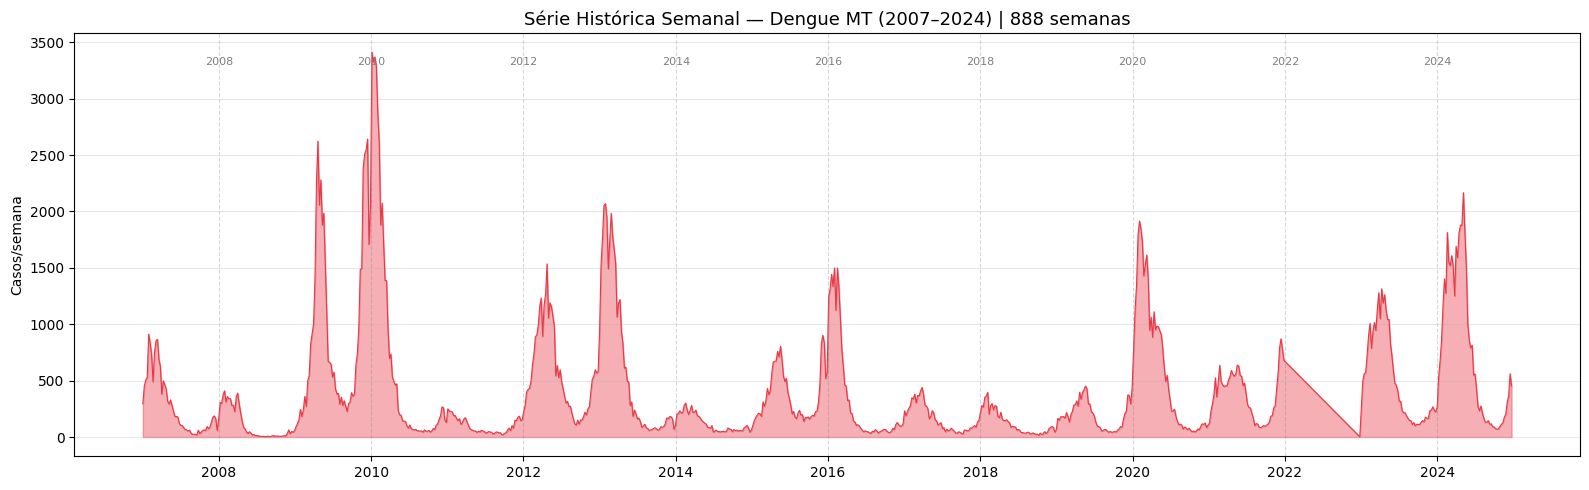

Série histórica visualizada!

Destaques:
  2010-01-04: 3,413 casos
  2010-01-18: 3,370 casos
  2010-01-11: 3,324 casos
  2010-01-25: 3,291 casos
  2010-02-01: 2,872 casos


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(serie_semanal['semana'], serie_semanal['casos'], 
                alpha=0.4, color='#e63946')
ax.plot(serie_semanal['semana'], serie_semanal['casos'], 
        color='#e63946', linewidth=0.8)

# Marcar anos
for ano in range(2008, 2025, 2):
    ax.axvline(pd.Timestamp(f'{ano}-01-01'), color='gray', 
               linestyle='--', alpha=0.3, linewidth=0.8)
    ax.text(pd.Timestamp(f'{ano}-01-01'), ax.get_ylim()[1]*0.92, 
            str(ano), ha='center', fontsize=8, color='gray')

ax.set_title('Série Histórica Semanal — Dengue MT (2007–2024) | 888 semanas', fontsize=13)
ax.set_ylabel('Casos/semana')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/fig21_serie_historica_completa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Série histórica visualizada!")
print(f"\nDestaques:")
top5 = serie_semanal.nlargest(5, 'casos')[['semana','casos']]
for _, row in top5.iterrows():
    print(f"  {row['semana'].date()}: {row['casos']:,} casos")

In [5]:
# Salvar série histórica consolidada
serie_semanal.to_parquet('../data/processed/serie_semanal_historica_2007_2024.parquet', index=False)

# Salvar também por município para TFT multi-município
casos_municipio_hist = (confirmados
    .groupby(['semana', 'ID_MUNICIP'])
    .size()
    .reset_index(name='casos')
    .sort_values(['ID_MUNICIP', 'semana'])
    .reset_index(drop=True))

casos_municipio_hist.to_parquet(
    '../data/processed/serie_municipios_historica_2007_2024.parquet', 
    index=False)

print(f"Série semanal MT salva: {len(serie_semanal)} semanas")
print(f"Série por município salva: {len(casos_municipio_hist):,} registros")
print(f"   Municípios únicos: {casos_municipio_hist['ID_MUNICIP'].nunique()}")
print(f"   Semanas únicas: {casos_municipio_hist['semana'].nunique()}")

Série semanal MT salva: 888 semanas
Série por município salva: 35,833 registros
   Municípios únicos: 142
   Semanas únicas: 888
